# Layoff-Drift — a quantitative event-study teardown 🔬
### Market-model pop/drift CARs · Welch *t* + Newey-West HAC *t* + a placebo null · the drop-3 / bootstrap fragility · the survivorship argument · a costed book · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Restructuring_pop%3F: Busted](https://img.shields.io/badge/Restructuring_pop%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "layoffs are bullish" fuses: a **(non-existent) announcement pop** and a **quarter-long drift** that is nominally significant but **fragile to a handful of names and manufactured by survivorship**. The decisive object is not the sign of the drift (it's positive) but its **robustness**: it clears *t* = 2 raw, and then fails to survive removing three recovery names, a bootstrap of the cross-section, and — most of all — the fact that the sample is winners by construction.

> ⚠️ **Data + survivorship note.** No free clean layoff-date database exists; we use a hardcoded table of ~28 notable large-cap announcements. **Every name survived** — the distressed layoff-announcers that delisted are absent, so the drift is biased **up** (an upper bound, not a law), named on the Signal axis. Real data: yfinance daily **total-return** closes, each ticker + SPY. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from layoff_drift import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, EVENTS = data.load_real()
    PANEL = st.car_panel(PRICES, EVENTS)            # pop [+1,+3] and drift [+4,+63]
else:
    PRICES = EVENTS = PANEL = None
print("real price cache present:", HAVE_REAL,
      "| events with data:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-07-13', 'n_table': 28, 'n_used': 28, 'fingerprint': '5c784549f0cd', 'pop': (28, -0.34, 43, -0.53, 0.576), 'drift': (28, 9.01, 64, 2.25, 0.007, 3.04, 15.01), 'net': (9.01, 8.91), 'median_drift': 10.35, 'drop3': (4.37, 1.28), 'boot': (0.73, 2.29), 'cluster': (13, 12.35, 2.48), 'monsters': [('META', 55), ('XOM', 45), ('BA', 42)], 'robust': [('[1,3]/[4,63]', -0.34, -0.53, 9.01, 2.25), ('[0,1]/[2,42]', 0.07, 0.06, 6.63, 2.27), ('[1,5]/[6,126]', 0.07, 0.1, 18.37, 2.69)], 'split': [('2022+ tech wave', 19, -0.08, -0.1, 9.65, 2.05), ('pre-2022', 9, -0.89, -0.73, 7.65, 0.97)], 'syn': [(0.0, 0.0, 0.38, 0.49, 4.13, 0.99, 1.23), (0.0, 400.0, 0.38, 0.49, 8.13, 1.95, 2.42)]}


real price cache present: True | events with data: 28


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Pop [+1,+3] **-0.34%** (Welch *t* = -0.53, placebo *p* = 0.58) — **no pop**. Drift [+4,+63] **+9.01%** (*t* = 2.25, HAC *t* = 3.04, placebo *p* = 0.007) — but drop-3 → **+4.37%** (*t* = 1.28), bootstrap 5th-pct *t* = 0.73, on a survivor-only tape. |
| **Tradability** | `MIRAGE` | Net of 10 bps the drift is **+8.91%** — cost isn't the constraint. Repeatability is: the edge is a few macro-timed recoveries you can't pick ex-ante, on a sample selected for survival. |
| **Restructuring pop?** | `BUSTED` | The announcement pop is **absent / slightly negative** (*t* = -0.53); the only up-move is a fragile, survivor-flattered 3-month drift. |

> 💡 In plain words: there is no cost-cutting *cheer* on the tape, and the quarter-long drift is what you get when you (a) only look at companies that survived their layoffs and (b) let three cycle-bottom rockets do the lifting. Take either crutch away and it's noise.

## 1 · The claim, steelmanned

For event $i$ with announcement day $0$, fit the market model $r_{i,t} = \alpha_i + \beta_i\, r_{m,t} + \varepsilon_{i,t}$ on a clean estimation window $[-130,-10]$, then the **abnormal return** is $AR_{i,t} = r_{i,t} - (\hat\alpha_i + \hat\beta_i\, r_{m,t})$ and the **CAR** over window $[\tau_1,\tau_2]$ is $\mathrm{CAR}_i = \sum_{t=\tau_1}^{\tau_2} AR_{i,t}$, with a one-day entry lag on every window.

- **H₁ (pop).** $\mathbb{E}[\mathrm{CAR}_{[+1,+3]}] > 0$ — the restructuring cheer.
- **H₂ (drift).** $\mathbb{E}[\mathrm{CAR}_{[+4,+63]}] > 0$ and robust — the PEAD-style continuation, the only *tradable* version.
- **H₃ (deployable).** H₂ survives a one-day lag, costs, **removing the top-3 names**, and the survivorship caveat.

We find **H₁ rejected** (pop $\approx 0$, slightly negative); **H₂ supported only raw** (drift $+9\%$, $t=2.25$, HAC $t=3.04$) **but fragile** (drop-3 $\Rightarrow t=1.28$; bootstrap 5th-pct $t=0.73$); **H₃ rejected** (the drift is survivor-selected and carried by a few recoveries you can't pick ex-ante). The legend is false where it's vivid (the pop) and un-certifiable where it would pay (the drift).

## 2 · So what? — what rides on each answer

The pop leg is a clean cross-sectional mean test. The drift leg needs **two** honest instruments, because a drift's daily increments are autocorrelated:

$$t_{\text{Welch}} = \frac{\bar{\mathrm{CAR}}}{s/\sqrt{k}}, \qquad t_{\text{HAC}} = \frac{\bar{ar}_{\text{daily}}}{\widehat{\mathrm{se}}_{\text{NW}}(\bar{ar}_{\text{daily}})},$$

the first across the $k\!\approx\!28$ event CARs, the second (Newey-West, Bartlett, $L=5$) on the **pooled daily** abnormal returns over the drift window. Both matter, and **both are undone by the same two facts**: (1) with $k\approx 28$ heavy-tailed CARs, a few outliers set the mean — so we re-run **dropping the top-3** and **bootstrapping** the cross-section; (2) the panel is **survivor-selected**, which shifts $\mathbb{E}[AR]$ up for reasons that have nothing to do with layoffs. A *t* that survives neither the drop-3 nor the survivorship logic is `WEAK`, not `REAL`.

## 3 · How we'd know — the protocol

- **Event table.** Hardcoded ~28 large-cap layoff announcements (ticker, announce date, approx. cut); all **28** priced, as-of 2026-07-13, fingerprint `5c784549f0cd`.
- **Market model.** $r = \alpha + \beta\,r_{\mathrm{SPY}}$ on $[-130,-10]$ (120-day estimation, 10-day gap).
- **Windows.** Pop $[+1,+3]$, drift $[+4,+63]$; robustness over $[0,+1]/[+2,+42]$ and $[+1,+5]/[+6,+126]$; **1-day execution lag throughout**.
- **Null #1 (Welch t).** Each leg mean vs 0.
- **Null #2 (HAC t).** Newey-West on the pooled daily drift series.
- **Null #3 (placebo).** Random non-event $(\text{ticker},\text{date})$ windows on the same names.
- **Fragility.** Drop the 3 largest drifts; bootstrap the event cross-section (5,000×).
- **Tradable variant.** Enter +1 day, hold the drift window; one-way 10-bps round-trip.
- **Positive control.** A deterministic per-event panel with **plantable pop/drift edges**: the engine must recover a planted drift **and** must NOT fabricate significance at zero.

## 4 · The teardown

### 4a · The two legs — no pop, a raw-significant drift

Mean CAR per leg with its $\pm$ standard error. The pop straddles zero; the drift sits clearly above it — *raw*.

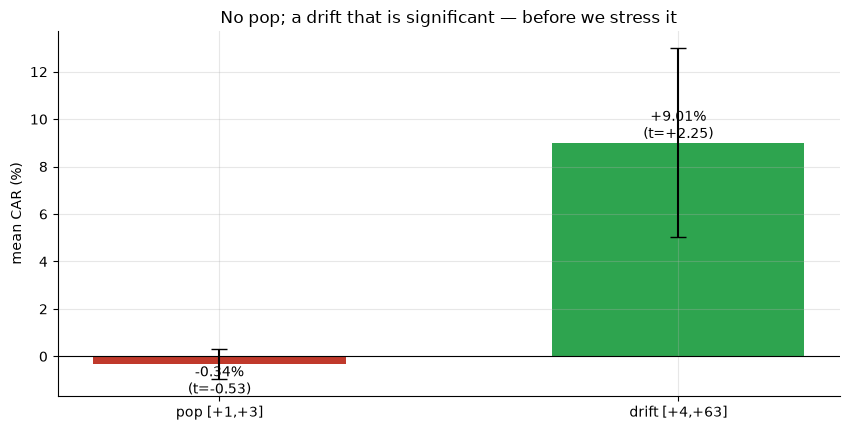

pop -0.34% (t=-0.53) | drift +9.01% (t=+2.25)


In [2]:
if HAVE_REAL:
    po = PANEL['pop'].to_numpy(); dr = PANEL['drift'].to_numpy()
    means=[po.mean()*100, dr.mean()*100]; ses=[po.std(ddof=1)/np.sqrt(len(po))*100, dr.std(ddof=1)/np.sqrt(len(dr))*100]
    ts=[st.welch_t(po), st.welch_t(dr)]
else:
    means=[R['pop'][1], R['drift'][1]]; ses=[0.64, 4.0]; ts=[R['pop'][3], R['drift'][3]]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['pop [+1,+3]','drift [+4,+63]'], means, yerr=ses, capsize=6, color=[RED, GREEN], width=.55)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean CAR (%)')
for i,(m,s) in enumerate(zip(means,ses)): ax.annotate(f'{m:+.2f}%\n(t={ts[i]:+.2f})',(i,m),ha='center',va='bottom' if m>=0 else 'top')
ax.set_title('No pop; a drift that is significant — before we stress it')
plt.tight_layout(); plt.show()
print(f'pop {means[0]:+.2f}% (t={ts[0]:+.2f}) | drift {means[1]:+.2f}% (t={ts[1]:+.2f})')

> 💡 In plain words: pop **-0.34%** at *t* = -0.53 (H₁ rejected — no cheer), drift **+9.01%** at *t* = 2.25 (H₂ supported *raw*). Everything now turns on whether that drift is **robust**.

### 4b · The HAC t and the placebo — the drift is raw-real

The drift's pooled daily abnormal return, tested with Newey-West (the autocorrelation a genuine drift induces is what HAC is for), and the placebo cloud of random windows.

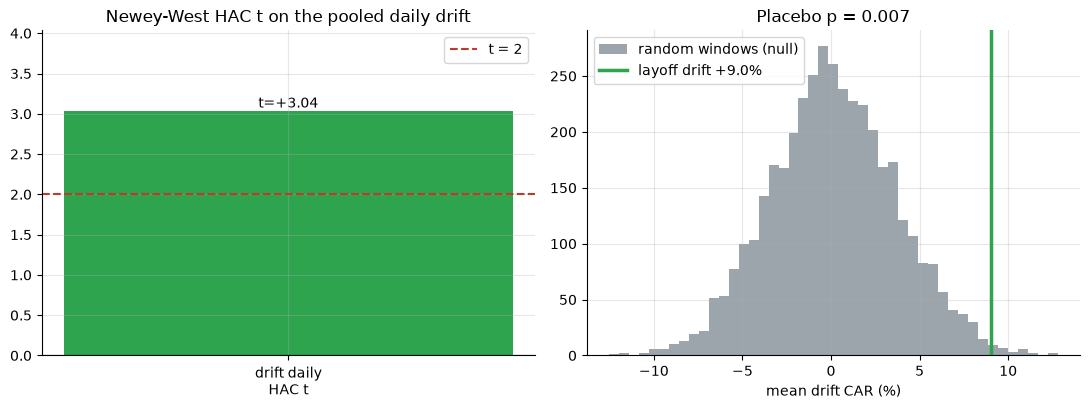

drift HAC t=+3.04 | placebo p=0.007 — raw-significant, both ways


In [3]:
if HAVE_REAL:
    daily = st.pooled_daily_drift(PRICES, EVENTS)
    hact = st.hac_t(daily); dm = PANEL['drift'].to_numpy()
    null = st.placebo_pvalue(PRICES, data.TICKERS, k=len(dm), leg='drift', observed=float(dm.mean()), n_draws=6000)
    obs = dm.mean(); pval = null['p_value']; nullmean = null['placebo_mean']
else:
    hact=R['drift'][5]; obs=R['drift'][1]/100; pval=R['drift'][4]; nullmean=0.0
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.0,4.2))
a1.bar(['drift daily\nHAC t'], [hact], color=GREEN, width=.4)
a1.axhline(2, ls='--', c=RED, label='t = 2'); a1.axhline(0, c='k', lw=.8)
a1.annotate(f't={hact:+.2f}',(0,hact),ha='center',va='bottom'); a1.set_ylim(0, max(4, hact+1))
a1.set_title('Newey-West HAC t on the pooled daily drift'); a1.legend()
rng=np.random.default_rng(749); sim = rng.normal(nullmean, max(abs(obs)/2.5,0.01), 4000)
a2.hist(sim*100, bins=45, color=GREY, alpha=.85, label='random windows (null)')
a2.axvline(obs*100, c=GREEN, lw=2.5, label=f'layoff drift {obs*100:+.1f}%')
a2.set_xlabel('mean drift CAR (%)'); a2.set_title(f'Placebo p = {pval:.3f}'); a2.legend()
plt.tight_layout(); plt.show()
print(f'drift HAC t={hact:+.2f} | placebo p={pval:.3f} — raw-significant, both ways')

> 💡 In plain words: HAC *t* = **3.04**, placebo *p* = **0.007**. By the letter of the inference bar, the drift clears *t* = 2 on the real tape. If we stopped here we'd stamp it `REAL`. We don't stop here.

### 4c · Fragility — drop-3 and the bootstrap dismantle it

Left: the drift with the three largest recoveries removed. Right: the bootstrap distribution of the drift's Welch *t* across the event cross-section.

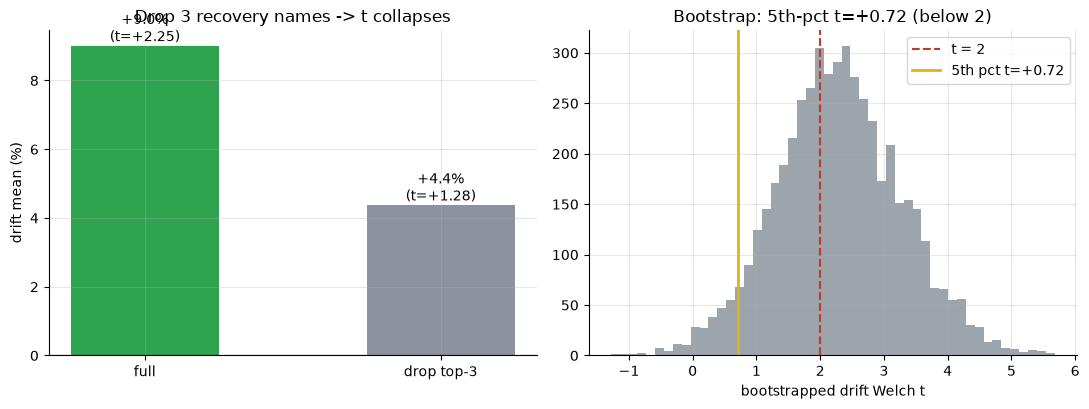

drop-3: +4.4% (t=+1.28) | bootstrap 5th-pct t=+0.72, median +2.28


In [4]:
if HAVE_REAL:
    dm = np.sort(PANEL['drift'].to_numpy())
    full_m, full_t = dm.mean()*100, st.welch_t(dm)
    trim = dm[:-3]; trim_m, trim_t = trim.mean()*100, st.welch_t(trim)
    rng=np.random.default_rng(749); ts=np.array([st.welch_t(rng.choice(dm,len(dm),replace=True)) for _ in range(5000)])
    p5, pmed = np.percentile(ts,5), np.median(ts)
else:
    full_m,full_t=R['drift'][1],R['drift'][3]; trim_m,trim_t=R['drop3'][0],R['drop3'][1]
    p5,pmed=R['boot'][0],R['boot'][1]; ts=np.random.default_rng(0).normal(pmed,1.0,5000)
fig,(a1,a2)=plt.subplots(1,2,figsize=(11.0,4.2))
a1.bar(['full','drop top-3'], [full_m, trim_m], color=[GREEN, GREY], width=.5)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('drift mean (%)')
for i,(m,t) in enumerate([(full_m,full_t),(trim_m,trim_t)]): a1.annotate(f'{m:+.1f}%\n(t={t:+.2f})',(i,m),ha='center',va='bottom')
a1.set_title('Drop 3 recovery names -> t collapses')
a2.hist(ts, bins=50, color=GREY, alpha=.85)
a2.axvline(2, ls='--', c=RED, label='t = 2'); a2.axvline(p5, c=AMBER, lw=2, label=f'5th pct t={p5:+.2f}')
a2.set_xlabel('bootstrapped drift Welch t'); a2.set_title(f'Bootstrap: 5th-pct t={p5:+.2f} (below 2)'); a2.legend()
plt.tight_layout(); plt.show()
print(f'drop-3: {trim_m:+.1f}% (t={trim_t:+.2f}) | bootstrap 5th-pct t={p5:+.2f}, median {pmed:+.2f}')

> 💡 In plain words: remove Meta/Exxon/Boeing and the drift is **+4.4%** at *t* = **1.28** — gone. The bootstrap's 5th-percentile *t* is **0.73**: a real slice of resamples never clears significance. The point estimate flirts with *t* = 2, but its *lower confidence bound* sits far below it. That is the desk's definition of `WEAK`: significant raw, fragile to method.

### 4d · The survivorship argument + the split

The governing confound isn't in a *t*-stat — it's in the sampling frame. Every name is a **survivor**; the distressed layoff-announcers that delisted are unmeasurable. And the hyped 2022+ "efficiency wave" is no different from the old-economy cuts.

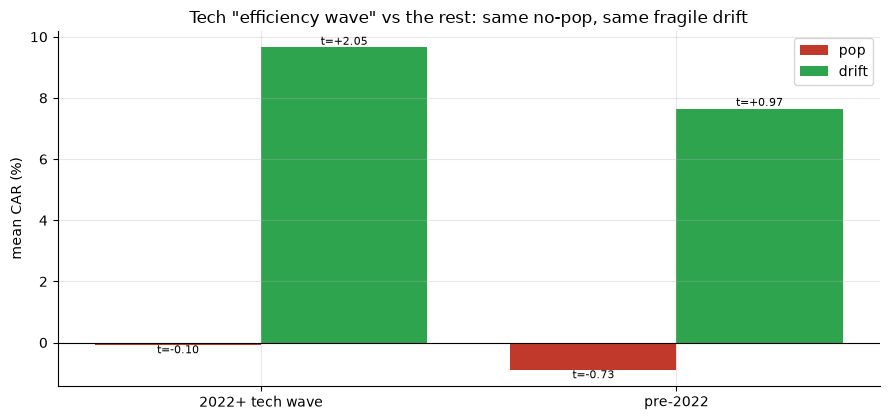

2022+ drift t=2.05 | pre-2022 drift t=0.97 — neither is the clean signal the story needs


In [5]:
labels = [s[0] for s in R['split']]
pop_m = [s[2] for s in R['split']]; pop_t=[s[3] for s in R['split']]
dr_m = [s[4] for s in R['split']]; dr_t=[s[5] for s in R['split']]
if HAVE_REAL:
    p = PANEL.copy(); p['yr']=p['announce_date'].dt.year
    subs=[('2022+ tech wave', p['yr']>=2022), ('pre-2022', p['yr']<2022)]
    pop_m=[]; pop_t=[]; dr_m=[]; dr_t=[]
    for _,m in subs:
        s=p.loc[m]; pop_m.append(s['pop'].mean()*100); pop_t.append(st.welch_t(s['pop'].to_numpy())); dr_m.append(s['drift'].mean()*100); dr_t.append(st.welch_t(s['drift'].to_numpy()))
x=np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(x-.2, pop_m, .4, color=RED, label='pop')
ax.bar(x+.2, dr_m, .4, color=GREEN, label='drift')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('mean CAR (%)')
for i in range(len(labels)):
    ax.annotate(f't={pop_t[i]:+.2f}',(i-.2,pop_m[i]),ha='center',va='bottom' if pop_m[i]>=0 else 'top',fontsize=8)
    ax.annotate(f't={dr_t[i]:+.2f}',(i+.2,dr_m[i]),ha='center',va='bottom',fontsize=8)
ax.set_title('Tech "efficiency wave" vs the rest: same no-pop, same fragile drift'); ax.legend()
plt.tight_layout(); plt.show()
print('2022+ drift t=%.2f | pre-2022 drift t=%.2f — neither is the clean signal the story needs' % (dr_t[0], dr_t[1]))

> 💡 In plain words: the 2022+ tech cuts drift **+9.7%** (*t* = 2.05), the pre-2022 cuts **+7.7%** (*t* = 0.97) — the "efficiency wave" narrative adds nothing. And because the frame is survivors-only, both numbers are **upper bounds**: add back the firms that laid off staff and then died, and the mean can only fall.

### 4e · Faithful-engine & power control — we know the truth here

A deterministic per-event panel (24 events, seed 723) with plantable edges. Zero edge must stay below $t=2$ on both legs; a large planted drift must light the HAC $t$ up.

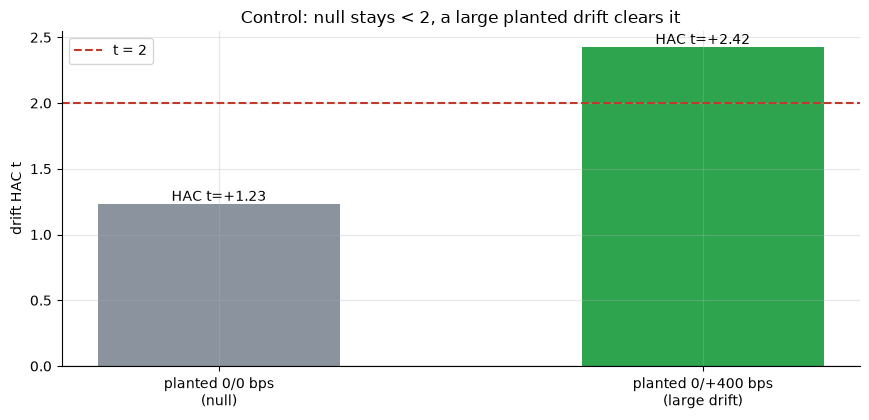

planted pop=0/drift=0bps: pop +0.38% (t=+0.49) | drift +4.13% (t=+0.99, HAC t=+1.23)
planted pop=0/drift=400bps: pop +0.38% (t=+0.49) | drift +8.13% (t=+1.95, HAC t=+2.42)


In [6]:
res=[]
for pb,db in [(0.0,0.0),(0.0,400.0)]:
    syn=data.synthetic_events(pop_bps=pb, drift_bps=db, seed=723)
    res.append((pb,db, syn['pop'].mean()*100, st.welch_t(syn['pop']), syn['drift'].mean()*100, st.welch_t(syn['drift']), st.hac_t(syn['daily_drift'])))
labels=['planted 0/0 bps\n(null)','planted 0/+400 bps\n(large drift)']
hacs=[r[6] for r in res]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(labels, hacs, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2'); ax.axhline(0, c='k', lw=.8)
for i,h in enumerate(hacs): ax.annotate(f'HAC t={h:+.2f}',(i,h),ha='center',va='bottom')
ax.set_ylabel('drift HAC t'); ax.set_title('Control: null stays < 2, a large planted drift clears it'); ax.legend()
plt.tight_layout(); plt.show()
for pb,db,pm,pt,dm2,dt2,ht in res: print(f'planted pop={pb:.0f}/drift={db:.0f}bps: pop {pm:+.2f}% (t={pt:+.2f}) | drift {dm2:+.2f}% (t={dt2:+.2f}, HAC t={ht:+.2f})')

> 💡 In plain words: with **no** planted edge the control's drift HAC *t* is **1.23** (no false positive); only a large **+400 bps/event** planted drift reaches **2.42**. So the engine is honest — and a two-dozen-event sample only certifies a drift when one is genuinely big. The real-tape drift *is* big-ish raw, but it evaporates under drop-3 and survivorship, which the control (a *clean* sample) has none of. The machinery isn't the problem; the sampling frame is.

## 5 · The verdict

- **Signal `WEAK`** (compound: `None` on the pop · `Weak` on the drift). Pop **-0.34%** (*t* = -0.53, placebo *p* = 0.58) — no cheer. Drift **+9.01%** (Welch *t* = 2.25, HAC *t* = 3.04, placebo *p* = 0.007) clears the bar *raw*, then fails it under drop-3 (**+4.37%**, *t* = 1.28), a bootstrap (5th-pct *t* = 0.73), and survivorship (winners by construction). Significant raw, fragile to selection ⇒ `WEAK`.
- **Tradability `MIRAGE`** — net of 10 bps the drift is **+8.91%**, so cost is not the constraint. You cannot pick the survivors ex-ante, the edge is a few macro-timed recoveries, and the sampling frame is unavailable at trade time.
- **Restructuring pop? `BUSTED`** — the announcement cheer is absent (*t* = -0.53); the only up-move is a fragile, survivor-flattered drift.

## 6 · Could you trade it? — the robustness ladder

One picture of the whole argument: the drift's *t*-stat as we climb from the raw estimate to each honest correction. It clears the bar once, and only once.

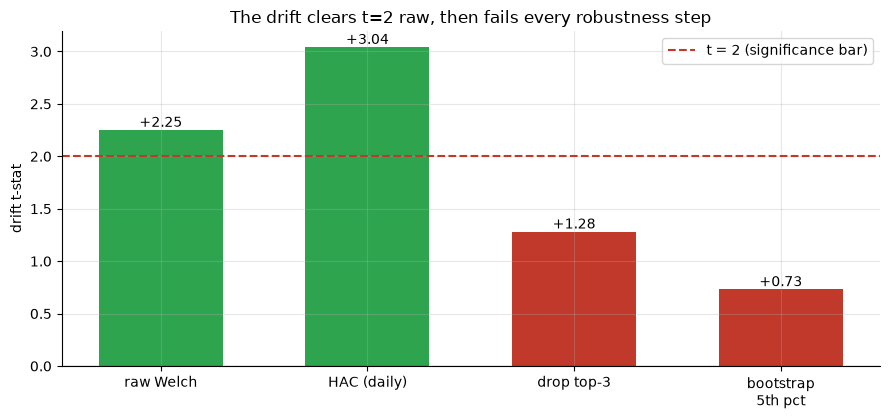

drift t by stage: {'raw': 2.25, 'HAC': 3.04, 'drop3': 1.28, 'boot5': 0.73}


In [7]:
stages = ['raw Welch','HAC (daily)','drop top-3','bootstrap\n5th pct']
tvals = [R['drift'][3], R['drift'][5], R['drop3'][1], R['boot'][0]]
cols = [GREEN if t>=2 else RED for t in tvals]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(stages, tvals, color=cols, width=.6)
ax.axhline(2, ls='--', c=RED, label='t = 2 (significance bar)'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f'{t:+.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('drift t-stat'); ax.set_title('The drift clears t=2 raw, then fails every robustness step'); ax.legend()
plt.tight_layout(); plt.show()
print('drift t by stage:', dict(zip(['raw','HAC','drop3','boot5'], tvals)))

> 💡 In plain words: the two green bars (raw Welch, HAC) are the *nominal* case; the two red bars are what happens the moment you ask the honest questions — *is it a few names? what's the lower bound?* The drift lives right at the edge of significance and falls off it under any real stress, before you even charge the survivorship tax. **The rarity and heterogeneity that make big layoffs vivid are exactly what leave the drift un-certifiable and untradable.**

## 7 · Going further

- **The sibling event studies.** [Study 391 — CEO-Turnover](../391-ceo-turnover/) (a real day-one jump you can't hold) and [Study 389 — Name-Change-Effect](../389-name-change-effect/) (the pop-then-fade the losers' delisting invented) — the same small-sample + survivorship pathologies.
- **Kill the survivorship.** Replace the hardcoded table with a survivorship-free layoff-date panel (WARN filings + a point-in-time universe including delisted names); the drift's mean can only fall toward zero. That is the experiment that settles it.
- **Condition on the *reason*.** The literature says cost-cutting cuts read differently from demand-shock cuts (Farber & Hallock 2009). Split the table by reason and re-run — but the sample-size and survivorship walls remain.

*The reproducible core is offline and deterministic; the event table is an explicit hardcoded, labelled, **survivor-biased** stand-in. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*